# Homework 7 - Chapter 12

- Due Date: Friday, March 13th no later than 11:59 p.m.
- Partner Information: You may complete this assignment individually or with exactly one classmate.
- Submission Instructions (working alone): Upload your solution, entitled **YourFirstName-YourLastName-Homework7.ipynb** to the 
Canvas Homework 7 Dropbox.
- Submission Instructions (working with one classmate): Upload your solution, entitled 
**YourFirstName-YourLastName-PartnerFirstName-PartnerLastName-Homework7.ipynb** to the Canvas Homework 7 Dropbox. Note: If you 
work with a partner, only one person needs to submit a solution. If you both submit a solution, the submission that will be graded is the one 
from the partner whose last name comes alphabetically first.
- Deadline Reminder: Once the submission deadline passes, Canvas will no longer accept your submission and you will no longer be able to earn credit. 
Thus, if you are not able to fully complete the assignment, submit whatever you have before the deadline so that partial credit can be earned.

## Starting Code

In [1]:
from datascience import *
%matplotlib inline
import numpy as np

Download the ab_test.csv file and place it
into the same directory as this Jupyter notebook.
The meaning of the columns is as follows:
- user_id: A unique id assigned to a visitor of a data science tutoring web site
- group: the web site experience given to the visitor: either **A** or **B**
- page_views: the number of different pages on the site the user visited
- time_spent: the number of seconds the user spent on the site
- conversion: **1** if the user purchased a tutoring session and **0** otherwise
- device: the type of device the user used to visit the site
- location: the visitor's general location

In [2]:
# Place the csv file in the same directory as your solution
ab_test = Table().read_table("ab_test.csv")
ab_test.show(3)

user_id,group,page_views,time_spent,conversion,device,location
9032,B,1,50,0,mobile,West Midlands
3463,A,3,159,1,mobile,South East
3864,A,1,50,0,mobile,London


## Question 1 - 2 Points

Ellingsen Incorporated, a data science tutoring conglomeration, has developed two different
website experiences for visitors and wants to learn if one experience
is more effective than the other in fostering the purchase of a tutoring session.
A user in **group A** receives one type of website experience and a user in 
**group B** receives a different experience.
A **conversion** of 1 means that the visitor purchased a tutoring session and a **conversion** of 0
means that they did not.

Create **Null and Alternative Hypotheses** for this study.

**Null Hypothesis ($H_0$):** The different websites have no effect on the conversion rate.

**Alternative Hypothesis ($H_a$):** The website for group A has a higher conversion rate than group B. 

## Question 2 - 1 Point

To begin the study, determine and print the conversion rates for both **group A** and **group B**. 
A conversion rate can range from 0.000 (0% conversions) to 1.000 (100% conversions).
Also, determine the difference between the two groups and use this
difference as the **Test Statistic**.  Your output should look something like this:

Group A Conversion Rate: 0.ddd     
Group B Conversions Rate: 0.ddd     
Test Statistic (Group A - Group B): 0.ddd

In [3]:
q2 = ab_test.with_column("count",1)
q2 = q2.group("group", sum)
numOfUsersA = q2.column("count sum")[0]
numOfUsersB = q2.column("count sum")[1]
groupA = ((q2.column("conversion sum")[0]) / numOfUsersA)
groupB = ((q2.column("conversion sum")[1]) / numOfUsersB)
print(f"Group A Conversion Rate: {groupA:.3f}")
print(f"Group B Conversion Rate: {groupB:.3f}")
testStat = groupA - groupB
print(f"Test Statistic (Group A - Group B): {testStat:.3f}")

Group A Conversion Rate: 0.150
Group B Conversion Rate: 0.120
Test Statistic (Group A - Group B): 0.030


## Question 3 - 2 Points

Perform a permutation test by shuffling the **group** column while keeping the **conversion** column fixed. 
For each permutation, calculate the test statistic and store the result in an array. 
Repeat this process 1000 times.
Print the resulting array (note: the array will show the first 3 numbers, followed by ..., followed by the final 3 numbers).

In [19]:
resultsArray = np.array([])
for i in range(1000):
    shuffledLabels = ab_test.sample(with_replacement = False).column("group")
    original_and_shuffled = ab_test.with_column("shuffled label", shuffledLabels)
    q3 = original_and_shuffled.with_column("count",1)
    q3 = q3.group("shuffled label", sum)
    numOfUsersA = q3.column("count sum")[0]
    numOfUsersB = q3.column("count sum")[1]
    groupA = ((q3.column("conversion sum")[0]) / numOfUsersA)
    groupB = ((q3.column("conversion sum")[1]) / numOfUsersB)
    testStat = groupA - groupB
    resultsArray = np.append(resultsArray, testStat)
print(resultsArray)

[-0.0052  0.0132  0.004   0.0004 -0.0028  0.002  -0.0048  0.0032 -0.0032
 -0.0032  0.01   -0.0048 -0.0008 -0.0096 -0.0056  0.0084 -0.0052  0.002
  0.002  -0.0164  0.0028 -0.008   0.0072  0.0004  0.0036 -0.008   0.0024
  0.     -0.0072  0.004   0.0028 -0.0044  0.0032  0.002   0.0164 -0.008
  0.0172 -0.0008 -0.0016  0.0112 -0.0016  0.0036  0.0016 -0.0088  0.0136
 -0.0008 -0.0048 -0.004  -0.0012 -0.0028 -0.0056 -0.0128  0.0072  0.0232
 -0.0052  0.0092  0.004   0.      0.002  -0.0068 -0.0104  0.0096  0.0116
 -0.0044 -0.006   0.0108  0.0012  0.0036 -0.0084 -0.0056  0.016  -0.0136
  0.0004  0.0008 -0.0064  0.0092  0.0076 -0.0016 -0.0052 -0.0024 -0.0092
  0.0072  0.0084  0.0104  0.0004  0.0072 -0.0028  0.0064  0.0068  0.0036
  0.0004 -0.0168 -0.0068 -0.0016 -0.0032  0.0052  0.0036 -0.0116  0.0016
  0.006   0.0036  0.0044 -0.0032  0.0036  0.0028 -0.012  -0.004  -0.0056
  0.0064 -0.0072  0.0016  0.008  -0.0016  0.0104 -0.0044 -0.0004 -0.0116
  0.0052  0.012   0.0012  0.014  -0.0016 -0.0016 -0.0

## Question 4 - 1 Point

Using the array created in question 3, create a histogram that displays the results.

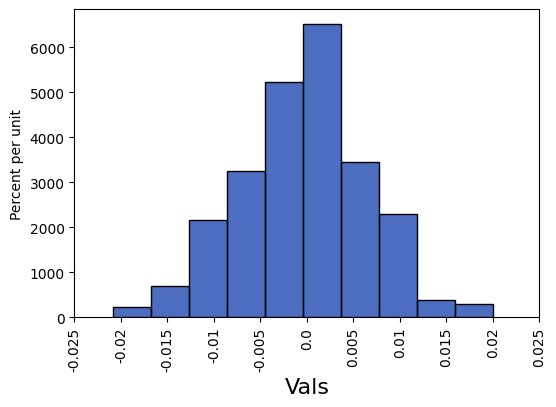

In [17]:
# Place answer here.
arr = Table().with_column("Vals", resultsArray)
arr.hist()

## Question 5 - 1 Point

Calculate and display the p-value, then form a conclusion reporting (1) whether the value is statistically significant,
highly statistically significant or neither and (2) whether the null hypothesis or alternative hypothesis is favored.

In [20]:
# Place p-value calculation and display here.
percent = (np.count_nonzero(resultsArray >= testStat) / len(resultsArray))
print(f"The p-value is {percent:.2f}")



The p-value is 0.60


**Conclusion:** 
The p-value is (p = 0.6). This result is not statistically significant, so we fail to reject the null hypothesis, meaning the null hypothesis is favored.

## Question 6 - 3 Points

Develop an insightful visualization that uses the provided csv file, Chapter 12 knowledge, and any other data science knowledge that you have previously learned.  Explain your visualization and what makes it insightful.

Observed Difference: -0.2504000000000133
P-value: 0.552


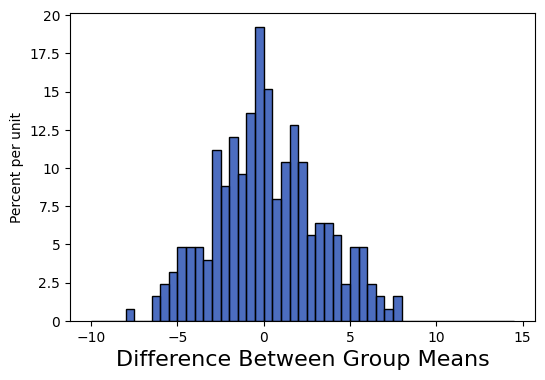

In [14]:
# Place visualization answer here.
means = ab_test.group("group", np.average)
observed_difference = (
    means.where("group", "B").column("time_spent average").item(0) -
    means.where("group", "A").column("time_spent average").item(0)
)


def one_simulated_difference(tbl):
    shuffled_tbl = tbl.sample(with_replacement = False)
    shuffled_tbl = shuffled_tbl.with_columns("group", tbl.column("group"))
    group_means = shuffled_tbl.group("group", np.average)
    return (
        group_means.where("group", "B").column("time_spent average").item(0) -
        group_means.where("group", "A").column("time_spent average").item(0)
    )

REPETITIONS = 250
differences = np.array([one_simulated_difference(ab_test) for _ in range(REPETITIONS)])

Table().with_column("Difference Between Group Means", differences).hist(bins=np.arange(-10, 15, 0.5))
print("Observed Difference:", observed_difference)

p_val = np.count_nonzero(differences >= observed_difference) / REPETITIONS
print("P-value:", p_val)

**Explanation -**

For this one, we are testing if the difference in the average time spent between group A and group B real or could it just be due to chance. So null hypothesis - groups dont matter.

To test this we calculated a sample of unique random groupings and then calculated the difference and kep track of it 250 times. The observed difference in average time spent between the two groups is -0.25 seconds which means Group B actually spent very slightly less time on the page. The p-value of 0.55 means that in 55% of our random shuffles, chance alone produced a difference this large or larger.
The p-value is 0.54 which means there is no statistically significant difference between the two groups with the time spent.